In [2]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [3]:
import os
import sys
import HeST as hest
import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import scipy
import glob
import pandas

plt.rcParams.update({'font.size': 14})

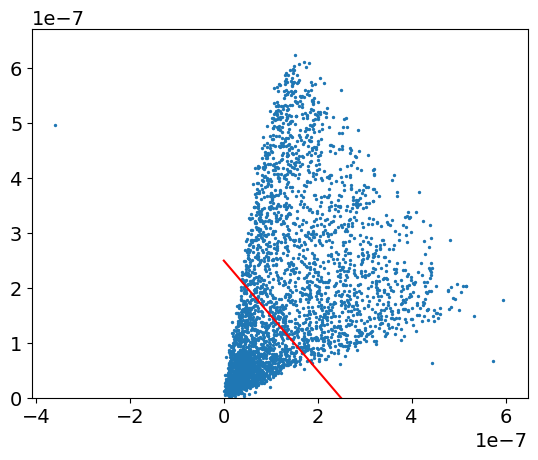

In [4]:

amps = np.load('./data/Double_pulse_amps.npy')
cpd_1_evap = amps[:,1]
cpd_2_scint = amps[:,2]
cpd_2_evap = amps[:,3]


plt.scatter(cpd_1_evap, cpd_2_evap, s = 2)
# make cuts to get rid of aluminum blob (I think)
def linear(x,a,b):
    return a * x + b
c1 = -1
c2 = 2.5e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.ylim(0, )


al_blob_cut = cpd_2_evap > linear(cpd_1_evap, c1, c2)

(0.0, 6e-07)

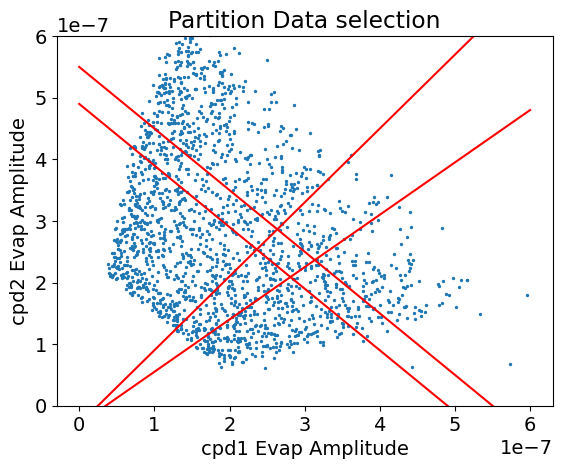

In [5]:
plt.scatter(cpd_1_evap[al_blob_cut], cpd_2_evap[al_blob_cut], s=2)
c1 = 1.2
c2 = -0.3e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.plot(x, linear(x, 0.85, -0.3e-7), 'r')


c1 = -1
c2 = 4.9e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')

c1 = -1
c2 = 5.5e-7
x = np.linspace(0,6e-7,100)
plt.plot(x, linear(x,c1,c2), 'r')
plt.ylim(0, )
plt.xlabel('cpd1 Evap Amplitude')
plt.ylabel('cpd2 Evap Amplitude')
plt.title('Partition Data selection')
plt.ylim(0, 0.6e-6)

In [6]:
params_1 = (1.2, -0.3e-7)
params_3 = (-1,  5.5e-7)
params_2 = (0.8, -0.3e-7)
params_4 = (-1, 4.9e-7)
cpd_2_evap = amps[:,3]
cpd_1_evap = amps[:,1]




# going to write the exclusion now. 
above_mask = (cpd_2_evap > linear(cpd_1_evap, *params_1)) | (cpd_2_evap > linear(cpd_1_evap, *params_3))
below_mask = (cpd_2_evap < linear(cpd_1_evap, *params_2)) | (cpd_2_evap < linear(cpd_1_evap, *params_4))

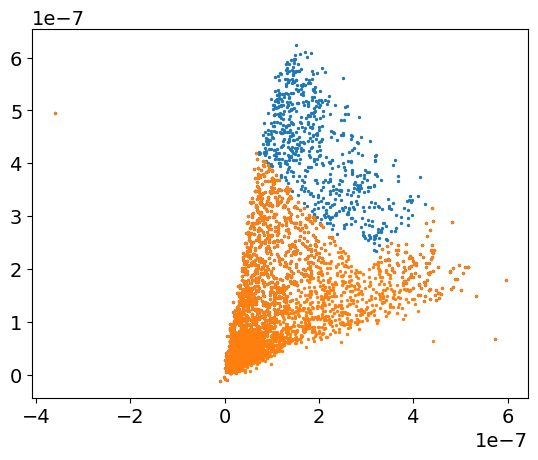

In [7]:
plt.scatter(cpd_1_evap[above_mask], cpd_2_evap[above_mask], s=2)

plt.scatter(cpd_1_evap[below_mask], cpd_2_evap[below_mask], s=2)

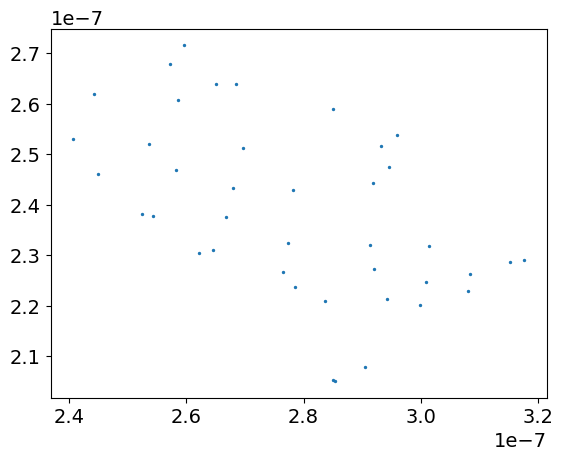

In [16]:
total_mask = above_mask | below_mask


plt.scatter(cpd_1_evap[~total_mask], cpd_2_evap[~total_mask], s=2)

In [14]:
print(list(total_mask).count(True))

5395


In [10]:
waves = np.load('./data/Double_pulse_wfs.npy')

amps = np.load('./data/Double_pulse_amps.npy')
cpd_1_evap = amps[:,1]
cpd_2_scint = amps[:,2]
cpd_2_evap = amps[:,3]



In [11]:
def running_average(N, data):
    if N <= 0:
        raise ValueError("N must be a positive integer")
    
    data = np.array(data)
    cumsum = np.cumsum(data)
    result = cumsum.copy()
    
    result[N:] = (cumsum[N:] - cumsum[:-N]) / N
    result[:N] = cumsum[:N] / np.arange(1, N + 1)
    
    return result

25000 40


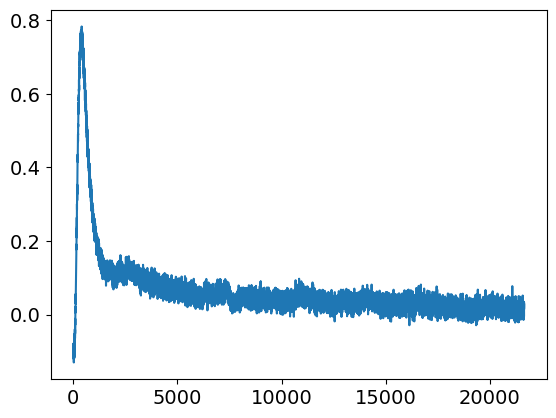

In [17]:
# so we need to subtract off the template * the amplitude at each point... how should I do this, maybe I can do this via a similar technique to the other plot
# first I need to match the template start time up with this, then subtract after scaling with amplitude.
# going to plot all the waveforms here I think
template_2 = np.load('./data/dispersion_curves/cpd2_scintillation.npy')
print(len(waves[0,0,:]), list(~total_mask).count(True))
big_array = np.zeros(shape=(len(waves[0,0,:]), list(~total_mask).count(True)))
for ii, (cpd_response, amps) in enumerate(zip(waves[~total_mask], cpd_2_scint[~total_mask])):
    # we want to normalize by amplirude
    response = cpd_response[1,:] - np.mean(cpd_response[1,0:2000])
    before_pad = 1870
    avg_response = running_average(100, response)
    amps = np.max(avg_response)
    after_pad = int(len(response) - before_pad - len(template_2))
    new_template = np.pad(template_2, (before_pad, after_pad), mode='constant', constant_values=0) * amps

    # plt.plot(response, 'k', label = 'Data')
    # plt.plot(new_template, 'r', label = f'fit {ii}')
    evaporation = response - new_template
    big_array[:, ii] = evaporation/np.max(evaporation)
    # plt.plot(evaporation/np.max(evaporation), 'k', label = f'Only Evaporation {ii}', alpha=0.5, linewidth=0.1 )

# plt.ylim(-0.5, 1)
averaged = np.mean(big_array, axis=1)

plt.plot(averaged[3350:])

